In [ ]:
pip install --user tqdm

### LeNet-5 예제 코드

코드에 필요한 라이브러리 호출

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
from PIL import Image
from tqdm import tqdm_notebook as tqdm
import random
from matplotlib import pyplot as plt

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


**이미지 데이터셋 전처리**
* torchvision 라이브러리: 이미지 전처리를 위한 라이브러리
* transforms.Compose: 이미지를 변형할 수 있는 방식들의 묶음
* transforms.RandomResizedCrop: 입력이미지를 주어진 크기로 조정. scale을 통해 임의의 크기(0.5 ~ 1.0 = 550 ~ 100%)만큼 면적을 무작위로 자름
* transforms.ToTensor: torchvision 메서드는 이미지를 읽을 때 PIL 라이브러리를 사용한다. PIL을 사용하면 생성되는 이미지는 범위가 0 ~ 255이고 H(높이) X W(너비) X C(채널 수)로 표현된다. 이후 효율적인 연산을 위해 torch.FloatTensor 배열로 바꿔야하는데, 이때 픽셀값의 범위는 0 ~ 1 사이가 되고 차원의 순서도 C(채널수)  X H(높이)X W(너비)로 바뀐다. 이 작업을 수행해주는 메서드가 ToTensor()이다.
* transforms.Normalize: 정규화
* __call__: 클래스를 호출할 수 있게 해준다. __init__ 은 인스턴스 초기화이고, __call__ 은 인스턴스가 호출되었을 때 실행된다.

In [ ]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform={
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }

  def __call__(self,img,phase):
    return self.data_transform[phase](img)

이미지 데이터셋을 불러오고 훈련, 검증, 테스트로 분리

In [ ]:
cat_directory=r'../dogs-vs-cats/Cat'
dog_directory=r'../dogs-vs-cats/Dog'

cat_images_filepaths=sorted([
    os.path.join(cat_directory,f) for f in os.listdir(cat_directory)
])
dog_images_filepaths=sorted([
    os.path.join(dog_directory,f) for f in os.listdir(dog_directory)
])
images_filepaths=[*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths=[i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths=correct_images_filepaths[:400] # 훈련용 400개 이미지
val_images_filepaths=correct_images_filepaths[400:-10] # 검증용 92개 이미지
test_images_filepaths=correct_images_filepaths[-10:] # 테스트로 10개 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

FileNotFoundError: [Errno 2] No such file or directory: '../dogs-vs-cats/Cat'

테스트 데이터셋 이미지 확인 함수

In [ ]:
def display_images_grid(images_filepaths, predicted_labels=(), cols=5):
  rows=len(images_filepaths)//cols
  figure, ax= plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
  for i, image_filepath in enumerate(images_filepaths):
    image=cv2.imread(image_filepath)
    image=cv2.cvtColor(image, cv2.COLOR_BAYER_BG2BGR)
    # 이미지 색상 변경, BGR->RGB 컬러로 변경
    true_label=os.path.norpath(image_filepath).splot(os.sep)[-2]
    # 이미지의 전체 경로를 정규화
    # split(os.sep) = 분할(경로를 /, \ 기준으로 분할)
    predicted_labels=predicted_labels[i] if predicted_labels else true_label
    color="green" if true_label == predicted_labels else "red"
    ax.ravel()[i].imshow(image) # 개별 이미지 출력
    ax.ravel()[i].set_title(predicted_labels, color=color) # prected_label을 title로 사용
    ax.ravel()[i].set_axis_off() # 이미지 축 제거
  plt.tight_layout() # 이미지의 여백을 조정
  plt.show()

# 테스트 데이터셋 이미지 출력
display_images_grid(test_images_filepaths)

이미지 데이터셋 클래스 정의

In [ ]:
class DogvsCatDatatset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'): #데이터셋 전처리
    self.file_list=file_list
    self.transform=transform
    self.phase=phase # train 적용

  def __len__(self): # images_filepaths 데이터셋의 전체 길이 반환
    return len(self.file_list)

  def __getitem__(self, idx): # 데이터셋에서 데이터를 가져옴, 결과는 텐서 형태
    img_path=self.file_list[idx]
    img=Image.open(img_path) # img_path 위치에서 이미지 데이터들을 가져온다.
    img_transformed=self.transform(img, self.phase)
    label=img_path.split('/')[-1].split('.')[0]
    if label == 'dog':
      label=1
    elif label == 'cat':
      label=0
    return img_transformed, label

변수 값 정의

In [ ]:
size=224
mean=(0.485, 0.456, 0.406)
std=(0.229, 0.224, 0.225)
batch_size=32

이미지 데이터셋 정의

In [ ]:
train_dataset= DogvsCatDatatset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train')
val_dataset=DogvsCatDatatset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index=0
print(train_dataset.__getitem__(index)[0].size())
print(train_dataset.__getitem__(index)[1])

데이터로더 정의

In [ ]:
train_dataloader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  # train_dataset: 데이터를 불러오기 위한 데이터셋
  # batch_size: 한번에 메모리로 불러올 데이터크기, 한번에 모든 데이터를 불러오면 메모리에 부담을 준다.
  # shuffle: 메모리로 데이터를 가져올 때 임의로 섞어서 가져오도록 한다.
val_dataloader=DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict={'train':train_dataloader, 'val':val_dataloader}

batch_iterator=iter(train_dataloader)
inputs, label=next(batch_iterator)
print(inputs.size())
print(label)

모델의 네트워크 클래스

**conv 에서 출력 크기 구하기: (W-F+2P)/S+1**
* W: 입력 데이터의 크기
* F: 커널 크기
* P: 패딩 크기
* S: 스트라이드

**MAXPOOL 에서 출력 크기 구하기: 1F/F**
* 1F: 입력 필터 크기
* F: 커널 크기




In [ ]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    self.cnn1=nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0)
    #2d 합성곱층: (3,224,224)가 입력되고, (16,220,220) 크기가 출력된다.
    self.relu1=nn.ReLU()
    self.maxpool1=nn.MaxPool2d(kernel_size=2)
    self.cnn2=nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
    self.relu2=nn.ReLU()
    self.maxpool2=nn.MaxPool2d(kernel_size=2)
    self.fc1=nn.Linear(32*53*53, 512)
    self.relu3=nn.ReLU()
    self.fc2=nn.Linear(512,2)
    self.output=nn.Softmax(dim=1)

  def forward(self, x):
    out=self.cnn1(x)
    out=self.relu1(out)
    out=self.maxpool1(out)
    out=self.cnn2(out)
    out=self.relu2(out)
    out=self.maxpool2(out)
    out=out.view(out.size(9), -1) #데이터를 1차원 형태로 바꿈
    out=self.fc1(out)
    out=self.fc2(out)
    out=self.output(out)
    return out

# 모델 객체 생성
model=LeNet()
print(model)

In [ ]:
pip install torchsummary

torchsummary 라이브러리를 통해 모델의 네트워크 구조를 확인한다.

In [ ]:
from torchsummary import summary
summary(model, input_size=(3,224,224))

학습 가능한 파라미터 수 확인하기

* 실행해보면 46038242 개의 파라미터가 나온다.
* 꽤 많은 파라미터를 학습해야해서 긴 시간이 걸릴 수 있다. 그래서 이미지 전체를 사용하는 것이 아닌 일부 이미지만 예제에서 사용한다.



In [ ]:
def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'the model has {count_parameters(model):, } trainable parameters')

옵티마이저와 손실함수
* 경사 하강법으로 모멘텀 SGD 사용: SGD에 관성이 추가된 방법, 매번 기울기를 구하지만 가중치를 수정하기 전에 이전 수정방향을 참고하여 같은 방향으로 일정한 비율만 수정되게 하는 방법
* SGD(model.parameters(), lr=0.001, momentum=0.9)
* model.parameters() : 경사하강법으로 업데이트하고자 하는 파라미터 -> weight, bias
* lr: learning rate: 가중치를 변경할 대 얼마나 크게 변경할지
* momentum: 관성

In [ ]:
optimizer=optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion=nn.CrossEntropyLoss()

모델 학습 함수 정의

In [ ]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
  since=time.time()
  best_acc=0.0

  #epoch 만큼 반복
  for epoch in range(num_epoch):
    print('epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in['train','val']:
      if phase=='train':
        model.train() # 모델을 학습
      else:
        model.eval()
    epoch_loss=0.0
    epoch_corrects=0

    # DataLoader에서 mini-batch 가져오기 dataloader_dict=훈련 데이터셋, train_loader
    for inputs, labels in tqdm(dataloader_dict[phase]): # tqdm: 진행률을 보여주는 역할
      inputs=inputs.to(device) # 훈련 데이터셋을 cpu에 할당
      labels=labels.to(device)
      optimizer.zero_grad() # 역전파 단계를 실행하기 전에 기울기(gradient)를 0으로 초기화

      with torch.set_grad_enabled(phase=='train'): # train 일때만 gradient 계산
        outputs=model(inputs) # 훈련 데이터셋을 모델에 넣음
        _, preds=torch.max(outputs, 1) # 각 이미지에서 가장 큰 값을 가진 클래스를 선택
        loss=criterion(outputs, labels) # 손실함수를 이용한 오차 계산

        if phase=='train': # train 일때만 역전파 backpropagation 실행
          loss.backward() # 모델의 학습 가능한 모든 파라미터에 대해 기울기를 계산
          optimizer.step() # optimizer의 step 함수를 호출하면 파라미터를 갱신

        # Loss 누적
        epoch_loss+= loss.item() * inputs.size(0) # 현재 batch의 loss 누적
        # loss.item()은 batch의 평균 loss * batch 사이즈 -> 현재 batch의 loss
        epoch_corrects+=torch.sum(preds==labels.data) # 맞힌 개수 누적

    epoch_loss=epoch_loss/len(dataloader_dict[phase].dataset) # 최종 오차 계산(오차를 데이터셋 길이로 나눠서 계산)
    epoch_acc=epoch_corrects.double()/len(dataloader_dict[phase].dataset)

    print('{} Loss: {:.4f} Acc: {:4f}'.format(phase, epoch_loss, epoch_acc))

    # 검증 데이터셋에 대한 가장 최적의 정확도를 저장
    if phase=='val' and epoch_acc > best_acc:
      best_acc=epoch_acc
      best_model_wts=model.state_dict()

  time_elapsed=time.time()-since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed%60))
  print('Best val Acc: {:4f}'.format(best_acc))
  return model



모델 학습

In [ ]:
import time
num_epoch=10
model=train_model(model, dataloader_dict, critertion, optimizer, num_epoch)

모델 테스트를 위한 함수 정의

In [ ]:
import pandas as pd

id_list=[]
pred_list=[]
_id=0
with torch.no_grad(): # 역전파 중 텐서들에 대한 변화도를 계산할 필요가 없다!
  for test_path in tqdm(test_images_filepaths): # 테스트 데이터셋 이용
    img=Image.open(test_path)
    _id=test_path.split('/')[-1].split('.')[1]
    transform=ImageTransform(size, mean, std)
    img=transform(img, phase='val') # 테스트 데이터셋 전처리 적용
    img=img.unsqueeze(0)
    # unsqueeze: 텐서에 차원을 추가!, (0)=차원이 추가될 위치
    # (2,2)인 2D 텐서 -> 0위치에차원을 추가 -> (1,2,2)3D 텐서
    img=img.to(device)

    model.eval()
    outputs=model(img)
    pred=F.softmax(outputs, dim=1)[:,1].tolist()
    # softmax: 지정된 차원(dim)을 따라 텐서의 요소(텐서의 개별값)가 (0,1) 범위에 있고 합계가 1이 되도록 크기를 재조정
    id_list.append(_id)
    pred_list.append(preds[0])

# 테스트 데이터셋의 예측 결과인 id와 레이블(label)을 데이터 프레임에 저장
res=pd.DataFrame({
    'id':id_list,
    'label':pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

rees.to_csv('../output/LeNet', index=False) # 데이터셋을 csv로 저장

테스트 데이터셋의 예측 결과호출

In [ ]:
res.head(10)

테스트 데이터셋이 이미지를 출력하기 위한 함수정의

In [ ]:
class_=classes=[0:'cat', 1: 'dog'] # 개 고양이에 대한 클래스 정의
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
  rows=len(images_filepaths)//cols
  figure, ax=plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))
  for i, image_filepath in enumerate(imges_filepaths):
    image= cv2.imread(image_filepath)
    image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    a= random.choice(res['id'].values) # 데이터 프레임의 id 라는 컬럼에서 임의로 데이터를 가져옴
    label=res.loc[res['id']==a, 'label'].values[0]
    if label>0.5:
      label=1
    else:
      label=0
    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(class_[label])
    ax.ravel()[i].set_axis_off()

  plt.tight_layout()
  plt.show()

# 결과 이미지 출력
display_image_grid(test_images_filepaths)

결과: 예측력이 그리 좋지 않음

전체 데이터를 쓴 게 아니라 일부만 썼기 때문



### AlexNet

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from forchvision import transforms
from torch.autograd import Variable
from torch import optim
import torch.nn as nn
import torch.nn.functional as F
import os
import cv2
import random
from PIL import Image
from tqdm import tdqm_notebook as tqdmd
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

데이터 전처리

In [ ]:
class ImageTransform():
  def __init__(self, resize, mean, std):
    self.data_transform={
        'train': transforms.Compose([
            transforms.RandomResizedCrop(resize, scale=(0.5,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ]),
        'val': transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean, std)
        ])
    }
  def __call__(self, img, phase):
    return self.data_transform[phase](img)


데이터를 가져와서 훈련, 검증, 테스트 용도로 분리

In [ ]:
cat_directory=r'../dogs-vs-cats/Cat'
dog_directory=r'../dogs-vs-cats/Dog'

cat_images_filepaths=sorted([
    os.path.join(cat_directory,f) for f in os.listdir(cat_directory)
])
dog_images_filepaths=sorted([
    os.path.join(dog_directory,f) for f in os.listdir(dog_directory)
])
images_filepaths=[*cat_images_filepaths, *dog_images_filepaths]
correct_images_filepaths=[i for i in images_filepaths if cv2.imread(i) is not None]

random.seed(42)
random.shuffle(correct_images_filepaths)
train_images_filepaths=correct_images_filepaths[:400] # 훈련용 400개 이미지
val_images_filepaths=correct_images_filepaths[400:-10] # 검증용 92개 이미지
test_images_filepaths=correct_images_filepaths[-10:] # 테스트로 10개 이미지
print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))

커스텀 데이터셋 정의

In [ ]:
# 강아지/고양이 이미지 파일 목록을 받아서,
# PyTorch가 학습에 사용할 수 있는 (이미지, 라벨) 형태로 하나씩 꺼내주는 Dataset 클래스
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transform=None, phase='train'):
    self.file_list=file_list
    self.transform=transform
    self.phase=phase

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, idx):
    img_path=self.file_list[idx] # 이미지 데이터의 인덱스 가져오기
    img=Image.open(img_path)
    img_transformed=self.transform(img, self.phase)

    label=img_path.split('/')[-1].split('.')[0]
    if label=='dog':
      label=1
    elif label=='cat':
      label=0


변수에 대한 값 정의

In [ ]:
size=256
mean=(0.485,0.456,0.406)
std=(0.229,0.224,0.225)
batch_size=32

훈련, 검증, 테스트 데이터셋 정의

In [ ]:
train_dataset=DogvsCatDataset(train_images_filepaths,
                              transform=ImageTransform(size, mean, std), phase='train')
val_dataset=DogvsCatDataset(val_images_filepaths,
                            transform=ImageTransform(size, mean, std), phase='val')
test_dataset=DogvsCatDataset(val_images_filepaths,
                            transform=ImageTransform(size, mean, std), phase='val')
index=0
print(train_dataset.__getitem__(index)[0].size()) # 훈련데이터셋 크기: (3,256,256)
print(train_dataset.__getitem__(index)[1])

데이터셋을 메모리로 불러옴

In [ ]:
train_dataloader=DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader=DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_dataloader=DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
dataloader_dict={'train':train_dataloader, 'val':val_dataloader}

batch_iterator=iter(train_dataloader)
inputs, label=next(batch_iterator)
print(inputs.size())
print(label)

AlexNet 모델 네트워크 정의
* 합성곱+ ReLU+ 풀링 : 5번 반복
* 2개의 완전연결층

In [ ]:
class AlexNet(nn.Module):
  def __init__(self) -> None:
    super(AlexNet, self).__init__()
    self.features=nn.Sequential(
        nn.Conv2d(3,64,kernel_size=11, stride=4, padding=2),
        nn.ReLU(inplace=True), # inplace:연산에 대한 결과값을 새로운 변수에 저장하는 것이 아닌, 기존 데이터를 대체하는 것
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(64,192,kernel_size=5, padding=2),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),

        nn.Conv2d(192,384, kernel_size=3, padding=1),
        nn.ReLU(inplace=True),

        nn.Conv2d(384,256, kernel_size=3,padding=2),
        nn.ReLU(inplace=True),

        nn.Conv2d(256,256, kernel_size=3,padding=1),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(kernel_size=3, stride=2),
    )
    self.avgpool=nn.AdaptiveAvgPool2d((6,6))
    self.classifier=nn.Sequential(
        nn.Dropout(),
        nn.Linear(256*6*6,4096),
        nn.ReLU(inplace=True),
        nn.Dropout(),
        nn.Linear(4096,512),
        nn.ReLU(inplace=True),
        nn.Linear(512,2))

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    x=self.features(x)
    x=self.avgpool(x)
    x=torch.flatten(x,1)
    x-self.classifier(x)
    return x


model 객체 생성

In [ ]:
model=AlexNet()
model.to(device)

옵티마이저 및 손실 함수 정의

In [ ]:
optimizer=optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
criterion=nn.CrossEntropyLoss()

모델 네트워크 구조 확인

In [ ]:
from torchsummary import summary
summary(model, input_size=(3,256,256))

모델 학습 함수 정의

In [ ]:
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
  since=time.time()
  best_acc=0.0

  #epoch 만큼 반복
  for epoch in range(num_epoch):
    print('epoch {}/{}'.format(epoch+1, num_epoch))
    print('-'*20)

    for phase in['train','val']:
      if phase=='train':
        model.train() # 모델을 학습
      else:
        model.eval()
    epoch_loss=0.0
    epoch_corrects=0

    # DataLoader에서 mini-batch 가져오기 dataloader_dict=훈련 데이터셋, train_loader
    for inputs, labels in tqdm(dataloader_dict[phase]): # tqdm: 진행률을 보여주는 역할
      inputs=inputs.to(device) # 훈련 데이터셋을 cpu에 할당
      labels=labels.to(device)
      optimizer.zero_grad() # 역전파 단계를 실행하기 전에 기울기(gradient)를 0으로 초기화

      with torch.set_grad_enabled(phase=='train'): # train 일때만 gradient 계산
        outputs=model(inputs) # 훈련 데이터셋을 모델에 넣음
        _, preds=torch.max(outputs, 1) # 각 이미지에서 가장 큰 값을 가진 클래스를 선택
        loss=criterion(outputs, labels) # 손실함수를 이용한 오차 계산

        if phase=='train': # train 일때만 역전파 backpropagation 실행
          loss.backward() # 모델의 학습 가능한 모든 파라미터에 대해 기울기를 계산
          optimizer.step() # optimizer의 step 함수를 호출하면 파라미터를 갱신

        # Loss 누적
        epoch_loss+= loss.item() * inputs.size(0) # 현재 batch의 loss 누적
        # loss.item()은 batch의 평균 loss * batch 사이즈 -> 현재 batch의 loss
        epoch_corrects+=torch.sum(preds==labels.data) # 맞힌 개수 누적

    epoch_loss=epoch_loss/len(dataloader_dict[phase].dataset) # 최종 오차 계산(오차를 데이터셋 길이로 나눠서 계산)
    epoch_acc=epoch_corrects.double()/len(dataloader_dict[phase].dataset)

    print('{} Loss: {:.4f} Acc: {:4f}'.format(phase, epoch_loss, epoch_acc))

    # 검증 데이터셋에 대한 가장 최적의 정확도를 저장
    if phase=='val' and epoch_acc > best_acc:
      best_acc=epoch_acc
      best_model_wts=model.state_dict()

  time_elapsed=time.time()-since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed//60, time_elapsed%60))
  print('Best val Acc: {:4f}'.format(best_acc))
  return model



모델 학습

In [ ]:
num_epoch=10
model=train_model(model, dataloader_dict, criterion,optimizer, num_epoch)

모델을 이용한 예측

In [ ]:
import pandas as pd

id_list=[]
pred_list=[]
_id=0

with torch.no_grad():
  for test_path in tqdm(test_images_filepaths):
    img= Image.open(test_path)
    _id= test_path.split('/')[-1].split('.')[1]
    transform= ImageTransform(size, mean, std)
    img= transform(img, phase='val')
    img= img.unsqueeze(0)
    img= img.to(device)

    model.eval()
    outputs= model(img)
    pred=F.softmax(outputs, dim=1)[:,1].tolist()

    id_list.append(_id)
    pred_list.append(preds[0])

# 데이터 프레임에 이미지의 id(번호)와 레이블을 저장
res=pd.DataFrame({
    'id':id_list,
    'label': pred_list
})
res.to_csv('../outputs/alexnet.csv', index=False)


In [ ]:
# 데이터 프레임 결과 확인
res.head(10)

예측결과르 시각적으로 표현하기 위한 함수 정의

In [ ]:
class_= classes = {0:'cat', 1: 'dog'}
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
  rows=len(images_filepaths)//cols
  figure, ax=plt.subplots(nrows=rows, ncols=cols, figsize=(12,6))

  for i, images_filepat in enumerate(images_filepaths):
    image= cv2.imread(images_filepaths)
    image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    a=random.choice(res['id'].values)
    lable=res.loc[res['id']==a, 'label'].values[0]

    if label>0.5:
      label=1
    else:
      label=0

    ax.ravel()[i].imshow(image)
    ax.ravel()[i].set_title(class_[label])
    ax.ravel()[i].set_axis_off()

  plt.tight_layout()
  plt.show()

In [ ]:
# 예측결과에 대해 이미지와 함께 출력
display_image_grid(test_images_filepaths)

### VGG

In [ ]:
import copy
import numpy as np
import torch
import torch.nn. as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as Datasets

device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

copy 에 대해 공부해보자
얕은 복사는 메모리 공간 1개에 A,B가 같이 저장되고, 깊은 복사는 메모리 공간 2개에 A, B가 각각 저장된다.

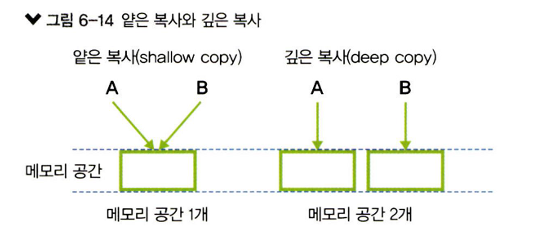

In [4]:
# 단순한 객체 복사 : 완전히 동일하게 복사
original=[1,2,3]
copy_o=original #shallow copy
print(copy_o) # [1, 2, 3]
copy_o[2]=10
print(copy_o) # [1, 2, 10]
print(original) # [1, 2, 10] # copy_o 뿐만 아니라 원래 값인 original의 3도 10으로 바뀐다!

# shallow copy 얕은 복사: 바깥 리스트는 새로 만든다.
import copy
original=[[1,2],3]
copy_o=copy.copy(original) # original 값을 copy_o에 얕은 복사
print(copy_o) # [[1, 2], 3]
copy_o[0]=100 # copy_o의 [1,2] 값을 100으로 변경
print(copy_o) # [100, 3]
print(original) # [[1, 2], 3] : original 안바뀜

append= copy.copy(original)
append[0].append(4) # 첫번째 리스트([1,2])에 4를 추가
print(append) # [[1, 2, 4], 3]
print(original) # [[1, 2, 4], 3] : original 바뀜

# 깊은 복사
import copy
original=[[1,2],3]
copy_o=copy.deepcopy(original) # original 값을 copy_o에 깊은 복사
print(copy_o) # [[1, 2], 3]
copy_o[0]=100
print(copy_o) # [100, 3]
print(original) # [[1, 2], 3]

append= copy.deepcopy(original)
append[0].append(4)
print(append) # [[1, 2, 4], 3]
print(original) # [[1, 2], 3]


[1, 2, 3]
[1, 2, 10]
[1, 2, 10]
[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2, 4], 3]
[[1, 2], 3]
[100, 3]
[[1, 2], 3]
[[1, 2, 4], 3]
[[1, 2], 3]


VGG 모델 정의

In [ ]:
class VGG(nn.Module):
  def __init__(self, features, output_dim):
    super().__init__()
    self.features= features # vgg 모델에 대한 매개변수에서 받아온 features 값을 self.features에 넣는다.
    self.avgpool=nn.AdaptiveAvgPool1d(7)
    self.classifier=nn.Sequential(
        nn.Linear(512*7*7, 4096),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Dropout(0.5),
        nn.Linear(4096, output_dim)
    )

  def forward(self, x):
    x= self.features(x)
    x= self.avgpool(x)
    h= x.view(x.shape[0],-1)
    x=self.classifier(h)
    return x, h

모델 유형 정의

In [ ]:
#8 합성곱 3 풀링층 => 전체 계층 11개
vgg11_config=[64,'M',128,'M',256, 256, 'M', 512,512 ,'M',512,512,'M'] # 숫자=conv, 'M'= 최대풀링
#10 합성곱 3 풀링층 => 전체 계층 13개
vgg13_config=[64,64,'M',128,128,'M',256, 256, 'M', 512,512 ,'M',512,512,'M']
#13 합성곱 3 풀링층 => 전체 계층 16개
vgg16_config=[64,64,'M',128,128,'M',256, 256,256,'M', 512,512,512,'M',512,512,512,'M']
#16 합성곱 3 풀링층 => 전체 계층 19개
vgg19_config=[64,64,'M',128,128,'M',256, 256,256,256,'M',512,512,512,512,'M',512,512,512,512,'M']

VGG 계층 정의

In [ ]:
def get_vgg_layers(config, batch_norm):
  layers=[]
  in_channels=3

  for c in config: # vgg11_config 값들을 가져온다.
    assert c== 'M' or isinstance(c, int)
    if c=='M': # 불러온 값이 'M' 이면 최대 풀링
      layers+= [nn.MaxPool2d(kernel_size=2)]
    else: # 불러온 값이 숫자이면 합성곱
      conv2d= nn.Conv2d(in_channels, c, kernel_size=3, padding=1)
      if batch_norm: # 배치 정규화
        layers+=[conv2d, nn.BatchNorm2d(c), nn.ReLU(inplace=True)] # 배치 정규화가 적용되면 정규화+RELU 적용
      else:
        layers+=[conv2d, nn.ReLU(inplace=True)] # 배치정규화가 적용되지 않으면 relu 만 적용
      in_channels=c

  return nn.Sequential(*layers)

In [ ]:
# 모델 계층 생성
vgg11_lyaers=get_vgg_layers(vgg11_config, batch_norm=True)

#vgg11 계층 확인
print(vgg11_layers)

# vgg11 전체에 대한 네트워크
OUTPUT_DIM=2
model=VGG(vgg11_layers, OUTPUT_DIM)
print(model)

사실 vgg 모델은 사전 훈련된 모델이다. 이미 누군가가 대용량의 이미지 데이터로 학습을 시켜서, 최상의 상태로 튜닝을 커쳐 모든 사람이 사용할 수 있또록 공유한 사전 훈련된 모델이다.

In [ ]:
# vgg11 사전 훈련된 모델 사용

import torchvision.models as models

pretrained_model=models.vgg11_bn(pretrained=True)
#vgg11_bn = vgg11 기본 모델에 배치 정규화가 이뤄진 모델
#pretrained=True: 사전 훈련된 모델을 사용한다는 의미
print(pretrained_model)

이미지 데이터 전처리
* transforms.RandomRotation: 5도 이하로 이미지 회전
* transforms.Resize: 이미지를 주어진 크기로 재조정

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(5),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

데이터셋 불러오기

In [ ]:
train_path = '../chap06/data/catanddog/train'
test_path = '../chap06/data/catanddog/test'

train_dataset = torchvision.datasets.ImageFolder(
    train_path,
    transform=train_transforms
)

test_dataset = torchvision.datasets.ImageFolder(
    test_path,
    transform=test_transforms
)

print(len(train_dataset)), print(len(test_dataset))

훈련과 검증 데이터 분할

In [ ]:
VALID_RATIO = 0.9

n_train_examples = int(len(train_dataset) * VALID_RATIO)
n_valid_examples = len(train_dataset) - n_train_examples

train_data, valid_data = data.random_split(
    train_dataset,
    [n_train_examples, n_valid_examples]
)

검증 데이터 전처리 및 훈련, 검증 테스트, 데이터셋 수 확인

In [ ]:
valid_data = copy.deepcopy(valid_data)
valid_data.dataset.transform = test_transforms

print(f'Number of training examples: {len(train_data)}')
print(f'Number of validation examples: {len(valid_data)}')
print(f'Number of testing examples: {len(test_dataset)}')

메모리로 데이터 불러오기

In [ ]:
BATCH_SIZE = 128

train_iterator = data.DataLoader(
    train_data,
    shuffle=True,
    batch_size=BATCH_SIZE
)

valid_iterator = data.DataLoader(
    valid_data,
    batch_size=BATCH_SIZE
)

test_iterator = data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)

옵티마이저 손실함수 정의

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

모델 정확도 측정

In [ ]:
def calculate_accuracy(y_pred, y):
    top_pred = y_pred.argmax(1, keepdim=True)
    correct = top_pred.eq(y.view_as(top_pred)).sum()
    acc = correct.float() / y.shape[0]
    return acc

모델 학습 함수 정의

In [ ]:
def train(model, iterator, optimizer, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.train()

    for (x, y) in iterator:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        y_pred, _ = model(x)

        loss = criterion(y_pred, y)
        acc = calculate_accuracy(y_pred, y)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

모델 성능 측정함수

In [ ]:
def evaluate(model, iterator, criterion, device):
    epoch_loss = 0
    epoch_acc = 0

    model.eval()

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)
            y = y.to(device)

            y_pred, _ = model(x)

            loss = criterion(y_pred, y)
            acc = calculate_accuracy(y_pred, y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(iterator), epoch_acc / len(iterator)

학습 시간 측정 함수

In [ ]:
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

모델 학습

In [ ]:
EPOCHS = 5

best_valid_loss = float('inf')

for epoch in range(EPOCHS):
    start_time = time.monotonic()

    train_loss, train_acc = train(
        model,
        train_iterator,
        optimizer,
        criterion,
        device
    )

    valid_loss, valid_acc = evaluate(
        model,
        valid_iterator,
        criterion,
        device
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(
            model.state_dict(),
            '../chap06/data/VGG-model.pt'
        )

    end_time = time.monotonic()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(
        f'Epoch: {epoch+1:02} | '
        f'Epoch Time: {epoch_mins}m {epoch_secs}s'
    )
    print(
        f'\tTrain Loss: {train_loss:.3f} | '
        f'Train Acc: {train_acc*100:.2f}%'
    )
    print(
        f'\t Valid. Loss: {valid_loss:.3f} | '
        f' Valid. Acc: {valid_acc*100:.2f}%'
    )

테스트 데이터셋을 이용한 모델 성능 측정

In [ ]:
model.load_state_dict(torch.load('../chap06/data/VGG-model.pt'))

test_loss, test_acc = evaluate(
    model,
    test_iterator,
    criterion,
    device
)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

테스트 데이터셋을 이용한 모델 예측확인 함수

In [ ]:
def get_predictions(model, iterator):
    model.eval()

    images = []
    labels = []
    probs = []

    with torch.no_grad():
        for (x, y) in iterator:
            x = x.to(device)

            y_pred, _ = model(x)

            y_prob = F.softmax(y_pred, dim=-1)

            top_pred = y_prob.argmax(1, keepdim=True)

            images.append(x.cpu())
            labels.append(y.cpu())
            probs.append(y_prob.cpu())

    images = torch.cat(images, dim=0)
    labels = torch.cat(labels, dim=0)
    probs = torch.cat(probs, dim=0)

    return images, labels, probs

정확하게 예측한 것을 추출

In [ ]:
images, labels, probs = get_predictions(model, test_iterator)

pred_labels = torch.argmax(probs, 1)

corrects = torch.eq(labels, pred_labels)

correct_examples = []

for image, label, prob, correct in zip(images, labels, probs, corrects):
    if correct:
        correct_examples.append((image, label, prob))

correct_examples.sort(
    reverse=True,
    key=lambda x: torch.max(x[2], dim=0).values
)

이미지 출력을 위한 전처리

In [ ]:
def normalize_image(image):
    image_min = image.min()
    image_max = image.max()

    image.clamp_(min=image_min, max=image_max)

    image.add_(-image_min).div_(image_max - image_min + 1e-5)

    return image

모델이 정확하게 예측한 이미지 출력함수

In [ ]:
def plot_most_correct(correct, classes, n_images, normalize=True):
    rows = int(np.sqrt(n_images))
    cols = int(np.sqrt(n_images))

    fig = plt.figure(figsize=(25, 20))

    for i in range(rows * cols):
        ax = fig.add_subplot(rows, cols, i + 1)

        image, true_label, probs = correct[i]

        image = image.permute(1, 2, 0)

        true_prob = probs[true_label]

        correct_prob, correct_label = torch.max(probs, dim=0)

        true_class = classes[true_label]
        correct_class = classes[correct_label]

        if normalize:
            image = normalize_image(image)

        ax.imshow(image.cpu().numpy())

        ax.set_title(
            f'true label: {true_class} ({true_prob:.3f})\n'
            f'pred label: {correct_class} ({correct_prob:.3f})'
        )

        ax.axis('off')

    fig.subplots_adjust(hspace=0.4)

예측 결과 이미지 출력

In [ ]:
classes=test_dataset.classes
N_IMAGES=5
plot_most_correct(correct_examples, classes, N_IMAGES)